In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
from langgraph.graph import StateGraph,START,END
from pydantic import BaseModel, Field
from langchain_groq import ChatGroq

In [3]:
class postState(BaseModel):
    topic: str = Field(description="The topic of the graph")
    post: str = Field(description="The LinkedIn post content")
    curated_post: str = Field(description="The curated LinkedIn post content")
    
    

In [4]:
llm = ChatGroq(
    model="openai/gpt-oss-20b"
)

In [5]:
def createPost(state: postState) -> postState:
    topic = state.topic
    post = llm.invoke(f"Write a LinkedIn post for {topic}").content
    state.post = post
    return state

In [6]:
def curatedPost(state: postState) -> postState:
    post = state.post
    curatedPost = llm.invoke(f"Curate the following LinkedIn post with GenZ tone: {post}").content
    
    state.curated_post = curatedPost
    return state

In [17]:
graph = StateGraph(postState)

graph.add_node("createPost", createPost)
graph.add_node("curatedPost", curatedPost)

graph.add_edge(START, "createPost")
graph.add_edge("createPost", "curatedPost")
graph.add_edge("curatedPost", END)



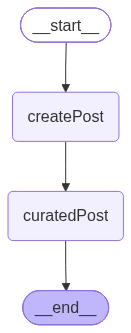

In [18]:
graph = graph.compile()
graph

In [21]:
res = graph.invoke({
    "topic": "The importance of data privacy in the digital age",
     "post": "",
     "curated_post": ""
})

print(res)


{'topic': 'The importance of data privacy in the digital age', 'post': '🚨 **Why Data Privacy Isn’t Just a “Nice‑to‑Have” – It’s a Business Imperative** 🚨\n\nIn the digital age, data is the new oil. Every click, swipe, and transaction generates a trail that can be mined for insights—but it also creates a trail that, if left unchecked, can be exploited.\n\n🔍 **The Numbers Speak for Themselves**\n- 70% of consumers say they would stop doing business with a company that experiences a data breach.  \n- The average cost of a data breach in 2025 is projected to hit **$9.5\u202fM** (IBM, 2024).  \n- GDPR fines can reach up to €20\u202fM or 4% of global turnover—whichever is higher.\n\n📈 **What’s at Stake?**\n- **Reputation:** A single breach can erode trust overnight.  \n- **Compliance:** Regulations (GDPR, CCPA, LGPD, etc.) are tightening.  \n- **Financials:** Fines, legal fees, and lost revenue can cripple even the most robust businesses.  \n- **Innovation:** Without a privacy‑first mindset,